In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("data.csv")
print("Shape: ", df.shape)
print("Columns: ", df.columns)
print("İsnull Values: ")
print(df.isnull().sum())
print("İnformations: ")
df.info()
display(df.head(5))

Shape:  (62184, 11)
Columns:  Index(['number_people', 'date', 'timestamp', 'day_of_week', 'is_weekend',
       'is_holiday', 'temperature', 'is_start_of_semester',
       'is_during_semester', 'month', 'hour'],
      dtype='object')
İsnull Values: 
number_people           0
date                    0
timestamp               0
day_of_week             0
is_weekend              0
is_holiday              0
temperature             0
is_start_of_semester    0
is_during_semester      0
month                   0
hour                    0
dtype: int64
İnformations: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62184 entries, 0 to 62183
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   number_people         62184 non-null  int64  
 1   date                  62184 non-null  object 
 2   timestamp             62184 non-null  int64  
 3   day_of_week           62184 non-null  int64  
 4   is_weekend       

,number_people,date,timestamp,day_of_week,is_weekend,is_holiday,temperature,is_start_of_semester,is_during_semester,month,hour
0,37,2015-08-14 17:00:11-07:00,61211,4,0,0,71.76,0,0,8,17
1,45,2015-08-14 17:20:14-07:00,62414,4,0,0,71.76,0,0,8,17
2,40,2015-08-14 17:30:15-07:00,63015,4,0,0,71.76,0,0,8,17
3,44,2015-08-14 17:40:16-07:00,63616,4,0,0,71.76,0,0,8,17
4,45,2015-08-14 17:50:17-07:00,64217,4,0,0,71.76,0,0,8,17


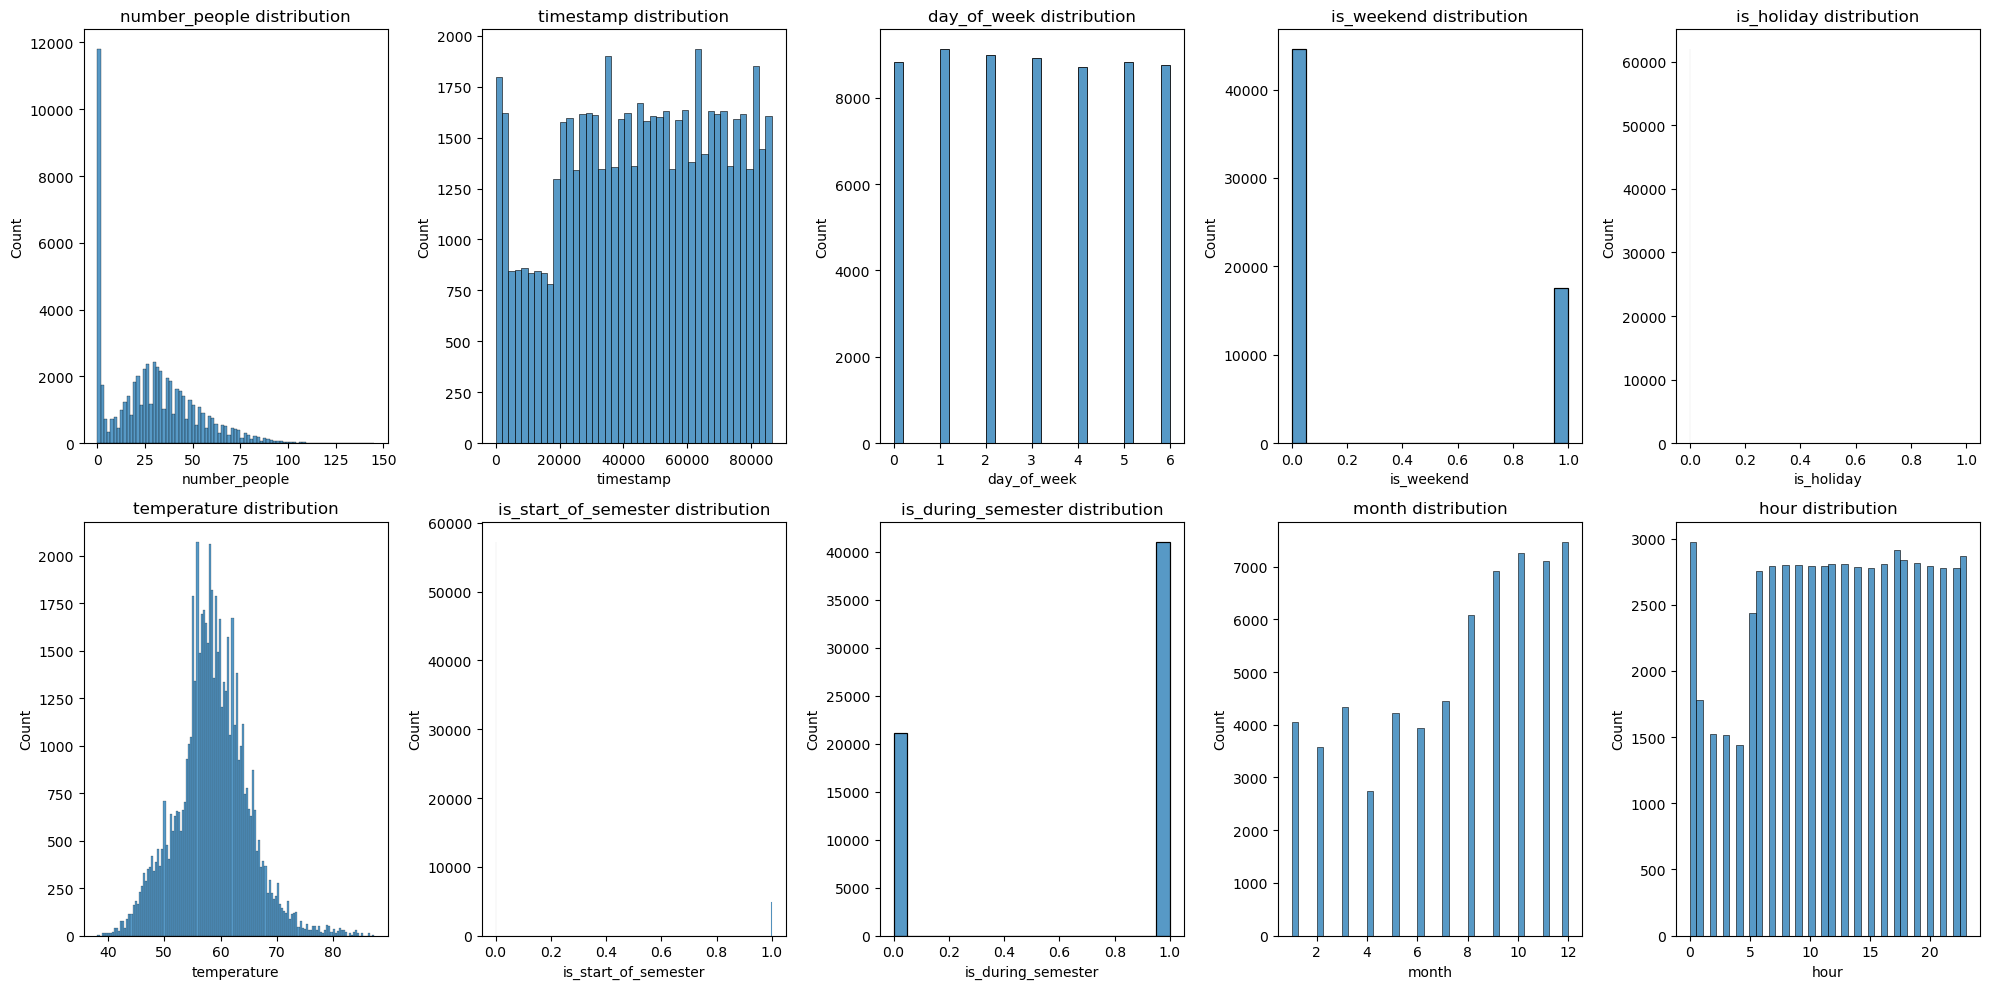

In [3]:
columns = [i for i in df.columns if i != "date"]
fig, ax = plt.subplots(2, 5, figsize=(20,10))
ax = ax.flatten()

for j, col in enumerate(columns):
    sns.histplot(
        data=df,
        ax=ax[j],
        x = col
    )
    ax[j].set_title(f"{col} distribution")

plt.tight_layout()
plt.show()

In [4]:
df["is_holiday"].value_counts()

is_holiday
0    62024
1      160
Name: count, dtype: int64

In [5]:
df["date"] = pd.to_datetime(df["date"], utc=True)
df["year"] = df["date"].dt.year
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62184 entries, 0 to 62183
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype              
---  ------                --------------  -----              
 0   number_people         62184 non-null  int64              
 1   date                  62184 non-null  datetime64[ns, UTC]
 2   timestamp             62184 non-null  int64              
 3   day_of_week           62184 non-null  int64              
 4   is_weekend            62184 non-null  int64              
 5   is_holiday            62184 non-null  int64              
 6   temperature           62184 non-null  float64            
 7   is_start_of_semester  62184 non-null  int64              
 8   is_during_semester    62184 non-null  int64              
 9   month                 62184 non-null  int64              
 10  hour                  62184 non-null  int64              
 11  year                  62184 non-null  int32              
dtypes: d

In [6]:
df = df.drop("date", axis=1)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62184 entries, 0 to 62183
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   number_people         62184 non-null  int64  
 1   timestamp             62184 non-null  int64  
 2   day_of_week           62184 non-null  int64  
 3   is_weekend            62184 non-null  int64  
 4   is_holiday            62184 non-null  int64  
 5   temperature           62184 non-null  float64
 6   is_start_of_semester  62184 non-null  int64  
 7   is_during_semester    62184 non-null  int64  
 8   month                 62184 non-null  int64  
 9   hour                  62184 non-null  int64  
 10  year                  62184 non-null  int32  
dtypes: float64(1), int32(1), int64(9)
memory usage: 5.0 MB


In [7]:
df["year"].value_counts()

year
2016    45539
2015    13529
2017     3116
Name: count, dtype: int64

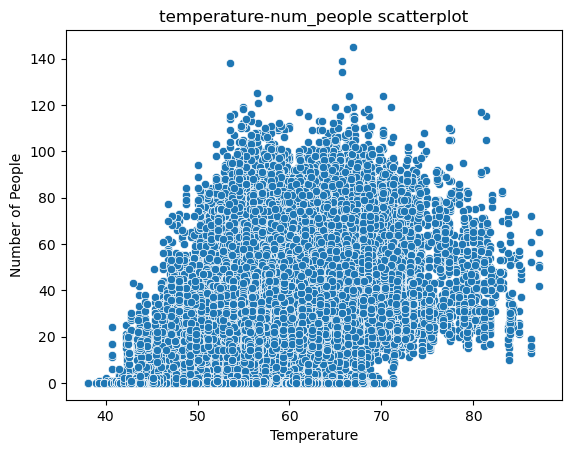

In [8]:
sns.scatterplot(x="temperature", y="number_people", data=df)
plt.xlabel("Temperature")
plt.ylabel("Number of People")
plt.title("temperature-num_people scatterplot")
plt.show()

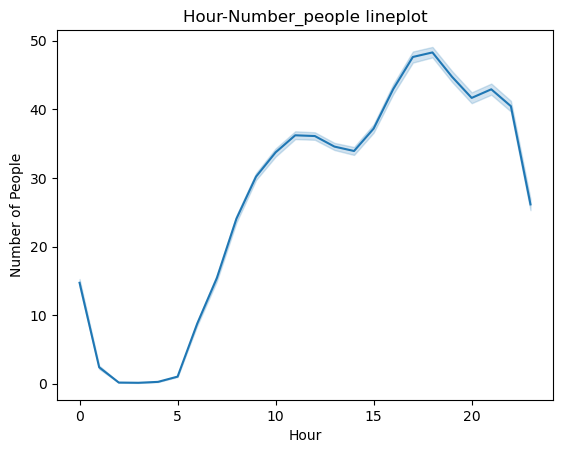

In [9]:
sns.lineplot(x="hour", y="number_people", data=df, estimator="mean")
plt.xlabel("Hour")
plt.ylabel("Number of People")
plt.title("Hour-Number_people lineplot")
plt.show()

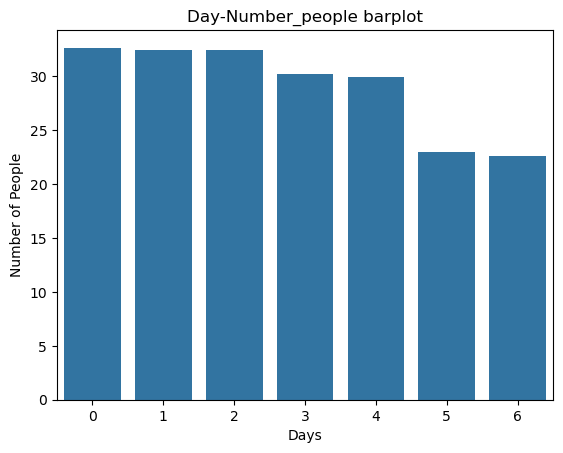

In [10]:
sns.barplot(x="day_of_week", y="number_people", estimator="mean", data=df, errorbar=None)
plt.xlabel("Days")
plt.ylabel("Number of People")
plt.title("Day-Number_people barplot")
plt.show()

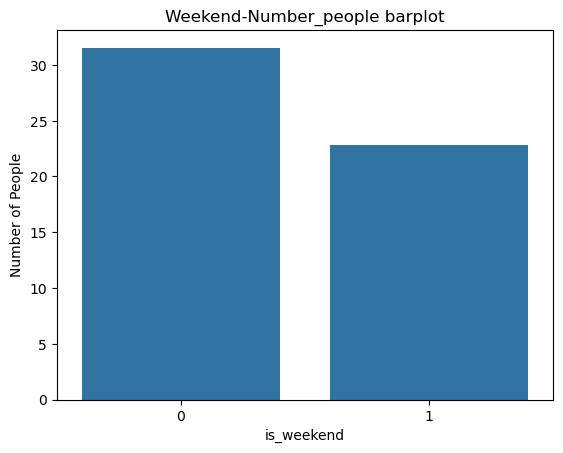

In [11]:
sns.barplot(x="is_weekend", y="number_people", estimator="mean", data=df, errorbar=None)
plt.xlabel("is_weekend")
plt.ylabel("Number of People")
plt.title("Weekend-Number_people barplot")
plt.show()

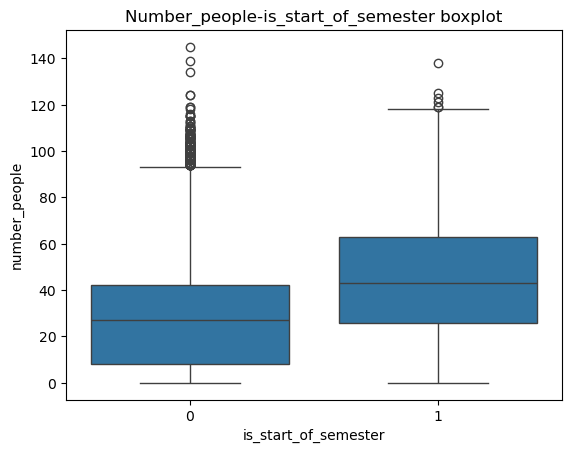

In [12]:
sns.boxplot(x="is_start_of_semester", y="number_people", data=df)
plt.title("Number_people-is_start_of_semester boxplot")
plt.show()

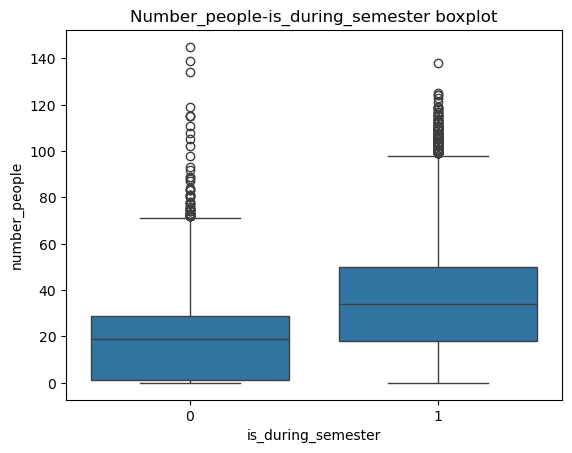

In [13]:
sns.boxplot(x="is_during_semester", y="number_people", data=df)
plt.title("Number_people-is_during_semester boxplot")
plt.show()

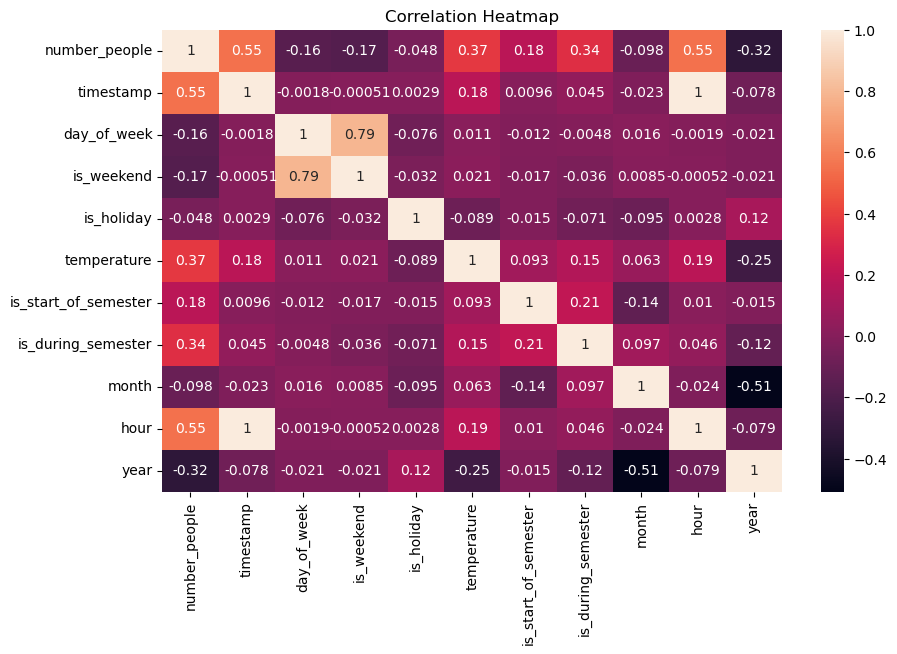

In [14]:
plt.figure(figsize=(10,6))
corr = df.corr()
sns.heatmap(corr, annot=True)
plt.title("Correlation Heatmap")
plt.show()

In [15]:
df = df.drop("timestamp", axis=1)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62184 entries, 0 to 62183
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   number_people         62184 non-null  int64  
 1   day_of_week           62184 non-null  int64  
 2   is_weekend            62184 non-null  int64  
 3   is_holiday            62184 non-null  int64  
 4   temperature           62184 non-null  float64
 5   is_start_of_semester  62184 non-null  int64  
 6   is_during_semester    62184 non-null  int64  
 7   month                 62184 non-null  int64  
 8   hour                  62184 non-null  int64  
 9   year                  62184 non-null  int32  
dtypes: float64(1), int32(1), int64(8)
memory usage: 4.5 MB


## Model Building

In [16]:
from sklearn.model_selection import train_test_split
X = df.drop("number_people", axis=1)
y = df["number_people"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=15)

In [17]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [18]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def calculate_metrics(true, predictions):
    mse = mean_squared_error(true, predictions)
    mae = mean_absolute_error(true, predictions)
    r2 = r2_score(true, predictions)
    return (mse, mae, r2)

def compare(model_dict, X_train, X_test, y_train, y_test):

    for i in range(len(list(model_dict.values()))):
        model = list(model_dict.values())[i]
        model.fit(X_train, y_train)

        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)

        train_mse, train_mae, train_r2 = calculate_metrics(y_train, y_train_pred)
        test_mse, test_mae, test_r2 = calculate_metrics(y_test, y_test_pred)

        print(list(model_dict.keys())[i])
        
        print("Evaluation for Training Set:")
        print("MSE: ", train_mse)
        print("MAE: ", train_mae)
        print("R2: ", train_r2)

        print("-----------------------")

        print("Evaluation for Test Set:")
        print("MSE: ", test_mse)
        print("MAE: ", test_mae)
        print("R2: ", test_r2)

        print("-----------------------")
        print("\n")

In [19]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(),
    "Lasso": Lasso(),
    "KNN": KNeighborsRegressor(),
    "SVR": SVR(),
    "Decision Tree Regressor": DecisionTreeRegressor(),
    "Random Forest Regressor": RandomForestRegressor()
}
compare(models, X_train_scaled, X_test_scaled, y_train, y_test)

Linear Regression
Evaluation for Training Set:
MSE:  205.15013531793016
MAE:  10.736278545598692
R2:  0.5990450245502594
-----------------------
Evaluation for Test Set:
MSE:  208.1786957813254
MAE:  10.772974414744663
R2:  0.6011719749263943
-----------------------


Ridge
Evaluation for Training Set:
MSE:  205.1501355032217
MAE:  10.736288598189768
R2:  0.5990450241881171
-----------------------
Evaluation for Test Set:
MSE:  208.1787548175835
MAE:  10.77298301042964
R2:  0.6011718618249353
-----------------------


Lasso
Evaluation for Training Set:
MSE:  212.26848320682976
MAE:  10.949098595750268
R2:  0.5851325940338805
-----------------------
Evaluation for Test Set:
MSE:  215.76875012334978
MAE:  10.968873724694198
R2:  0.5866309750797496
-----------------------


KNN
Evaluation for Training Set:
MSE:  30.754328248483738
MAE:  3.7234975188384487
R2:  0.9398923090704571
-----------------------
Evaluation for Test Set:
MSE:  53.71072898799313
MAE:  4.932761578044597
R2:  0.8971011

In [23]:
from sklearn.model_selection import RandomizedSearchCV

def show_best_params():
    knn_params = {
        "n_neighbors": [2,7,10,20,50]
    }
    rfr_params = {
        "n_estimators": [100,200,300,500],
        "max_depth": [2,3,5,7,10,15,None],
        "max_features": ["sqrt","log2",5,6,7,8],
        "min_samples_split": [2,3,5,10,20,50]
    }
    randomcv_models = [
        ("KNN", KNeighborsRegressor(), knn_params),
        ("RFR", RandomForestRegressor(), rfr_params)
    ]

    for name, model, param in randomcv_models:
        rcv = RandomizedSearchCV(estimator=model, param_distributions=param, n_jobs=-1, cv=5, n_iter=100)
        rcv.fit(X_train_scaled, y_train)
        print(rcv.best_params_)

show_best_params()

{'n_neighbors': 2}
{'n_estimators': 300, 'min_samples_split': 5, 'max_features': 6, 'max_depth': None}


In [26]:
models2 = {
    "KNN": KNeighborsRegressor(n_neighbors=2),
    "RandomForestRegressor": RandomForestRegressor(n_estimators=300, min_samples_split=5, max_features=6, max_depth=None)
}
compare(models2, X_train_scaled, X_test_scaled, y_train, y_test)

KNN
Evaluation for Training Set:
MSE:  29.085915962139314
MAE:  3.4953937695276602
R2:  0.9431531317176104
-----------------------
Evaluation for Test Set:
MSE:  48.2802583619211
MAE:  4.675064322469983
R2:  0.90750484808131
-----------------------


RandomForestRegressor
Evaluation for Training Set:
MSE:  22.400740768464647
MAE:  3.222593583246381
R2:  0.9562189493516228
-----------------------
Evaluation for Test Set:
MSE:  41.242596618320555
MAE:  4.318458476187716
R2:  0.9209875760991885
-----------------------


